### Customer Churn Prediction & Retention Analysis
### E-Commerce Retail Analytics

**Objective:** Identify at-risk customers using RFM analysis and predict churn using XGBoost. Export clean data for Power BI dashboard.


In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.14t.exe -m pip install --upgrade pip


## 📦 Phase 1 — Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 🗂️ Phase 2 — Data Loading & Cleaning

In [3]:
# Load both sheets from the Excel file
df_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010', dtype={'Customer ID': str})
df_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', dtype={'Customer ID': str})

df = pd.concat([df_2009, df_2010], ignore_index=True)

print(f'Raw dataset shape: {df.shape}')
df.head()

Raw dataset shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [4]:
# ── Basic info ──
print('\n📋 Column Info:')
print(df.dtypes)
print(f'\n❌ Missing values:\n{df.isnull().sum()}')


📋 Column Info:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
dtype: object

❌ Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [5]:
# ── Cleaning Steps ──

# 1. Drop rows with missing Customer ID (can't attribute transactions)
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 3. Remove negative or zero quantity/price (data errors)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4. Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['Price']

# 5. Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 6. Keep only UK customers for simplicity (largest segment)
df = df[df['Country'] == 'United Kingdom']

print(f'✅ Clean dataset shape: {df.shape}')
print(f'   Unique customers: {df["Customer ID"].nunique():,}')
print(f'   Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head()

✅ Clean dataset shape: (725250, 9)
   Unique customers: 5,350
   Date range: 2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


---
## 🔍 Phase 3 — Exploratory Data Analysis (EDA)

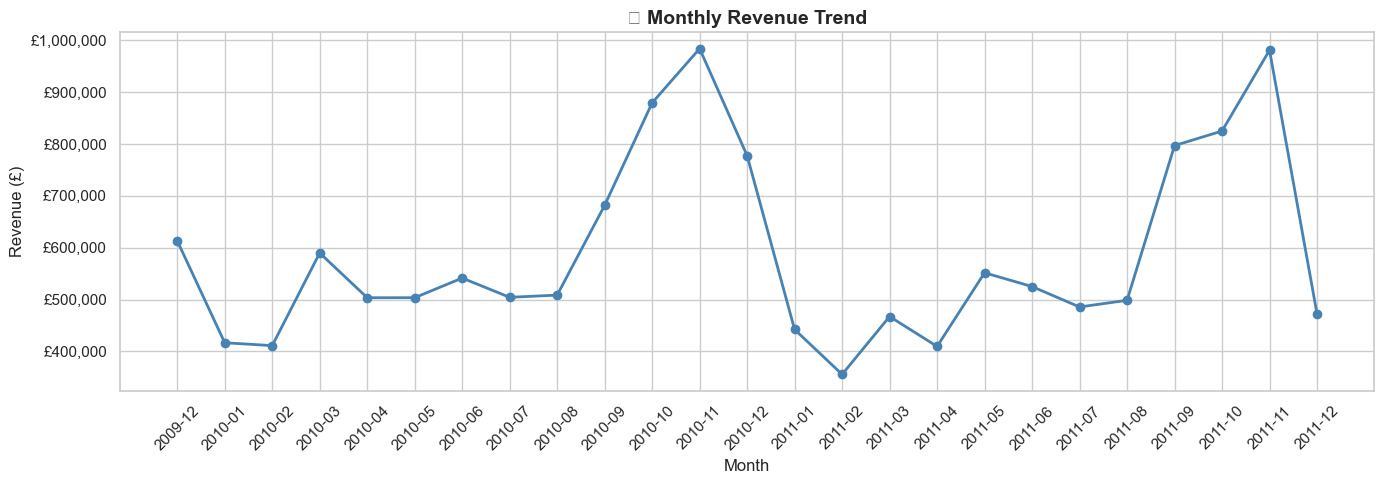

💾 Saved: monthly_revenue.png


In [6]:
# ── Monthly Revenue Trend ──
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum().reset_index()
monthly_revenue['InvoiceDate'] = monthly_revenue['InvoiceDate'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['InvoiceDate'], monthly_revenue['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.title('📈 Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: monthly_revenue.png')

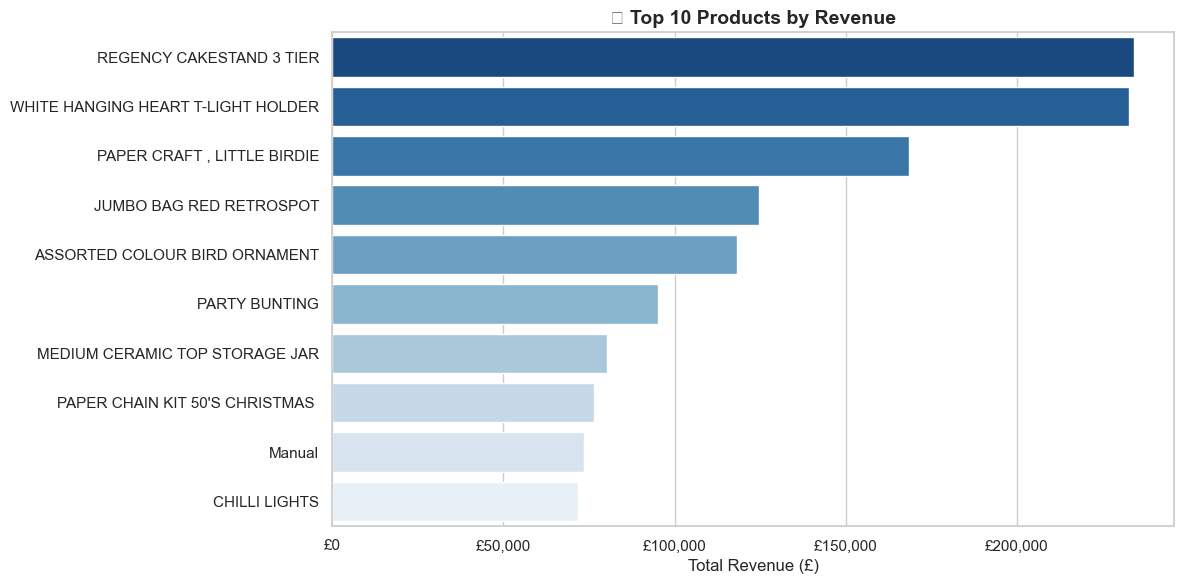

In [7]:
# ── Top 10 Products by Revenue ──
top_products = (df.groupby('Description')['TotalPrice']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, y='Description', x='TotalPrice', palette='Blues_r')
plt.title('🏆 Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

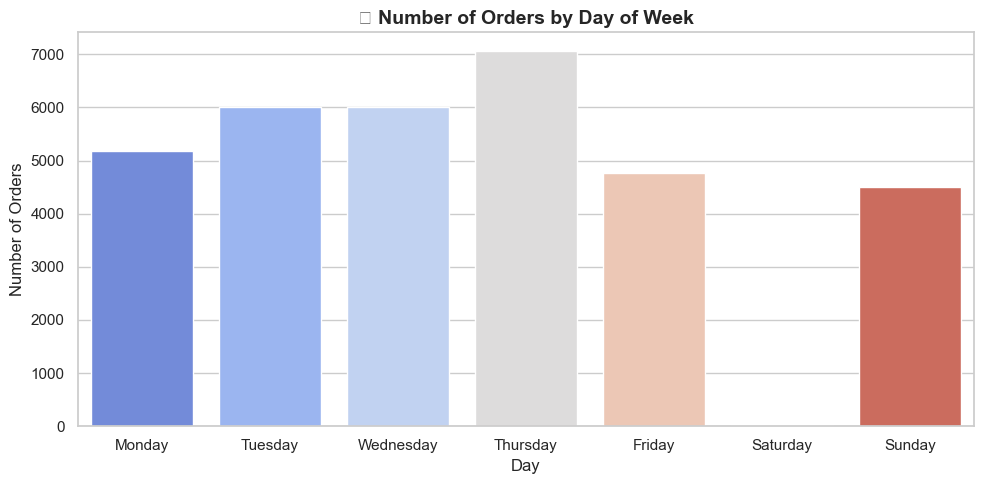

In [8]:
# ── Orders by Day of Week ──
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='coolwarm')
plt.title('📅 Number of Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('orders_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Phase 4 — RFM Feature Engineering

**RFM** is the gold standard customer segmentation model in retail:
- **Recency (R)** — How recently did a customer buy? (Lower = better)
- **Frequency (F)** — How often do they buy?
- **Monetary (M)** — How much do they spend?

In [9]:
# Reference date = 1 day after last transaction (simulates 'today')
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
print(f'📅 Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f'\n✅ RFM table shape: {rfm.shape}')
rfm.describe().round(2)

📅 Snapshot date: 2011-12-10

✅ RFM table shape: (5350, 4)


,Recency,Frequency,Monetary
count,5350.00,5350.00,5350.00
mean,203.00,6.27,2751.99
std,209.96,12.00,12080.47
min,1.00,1.00,2.95
25%,26.00,1.00,336.17
50%,98.50,3.00,849.91
75%,382.00,7.00,2214.91
max,739.00,336.00,608821.65


In [10]:
# ── RFM Score (1–5 quintile scoring) ──
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])  # Lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (rfm['R_Score'].astype(int) +
                    rfm['F_Score'].astype(int) +
                    rfm['M_Score'].astype(int))

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,12
1,12608,405,1,415.79,2,1,2,5
2,12745,487,2,723.85,1,2,3,6
3,12746,541,1,254.55,1,1,1,3
4,12747,2,26,9276.54,5,5,5,15


In [11]:
# ── Customer Segments based on RFM ──
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 3:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

seg_counts = rfm['Segment'].value_counts()
print('📊 Customer Segments:')
print(seg_counts)

📊 Customer Segments:
Segment
Lost                   1393
Loyal Customers        1276
Champions              1193
At Risk                 496
New Customers           402
Potential Loyalists     345
Cannot Lose Them        245
Name: count, dtype: int64


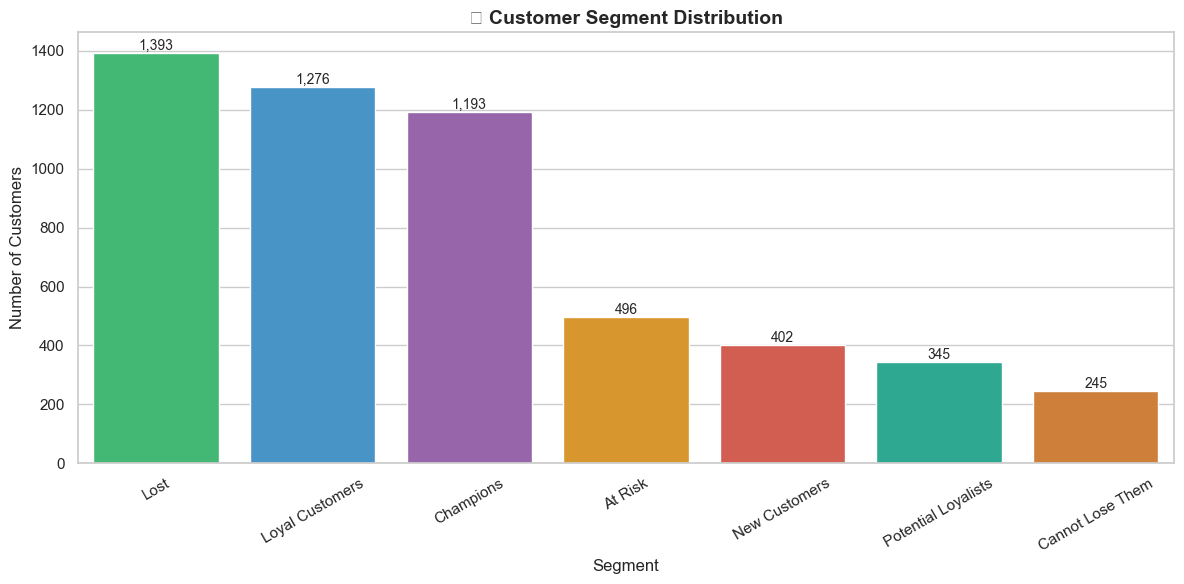

In [12]:
# ── Segment Distribution Chart ──
colors = ['#2ecc71','#3498db','#9b59b6','#f39c12','#e74c3c','#1abc9c','#e67e22','#95a5a6']

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=colors[:len(seg_counts)])
plt.title('👥 Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

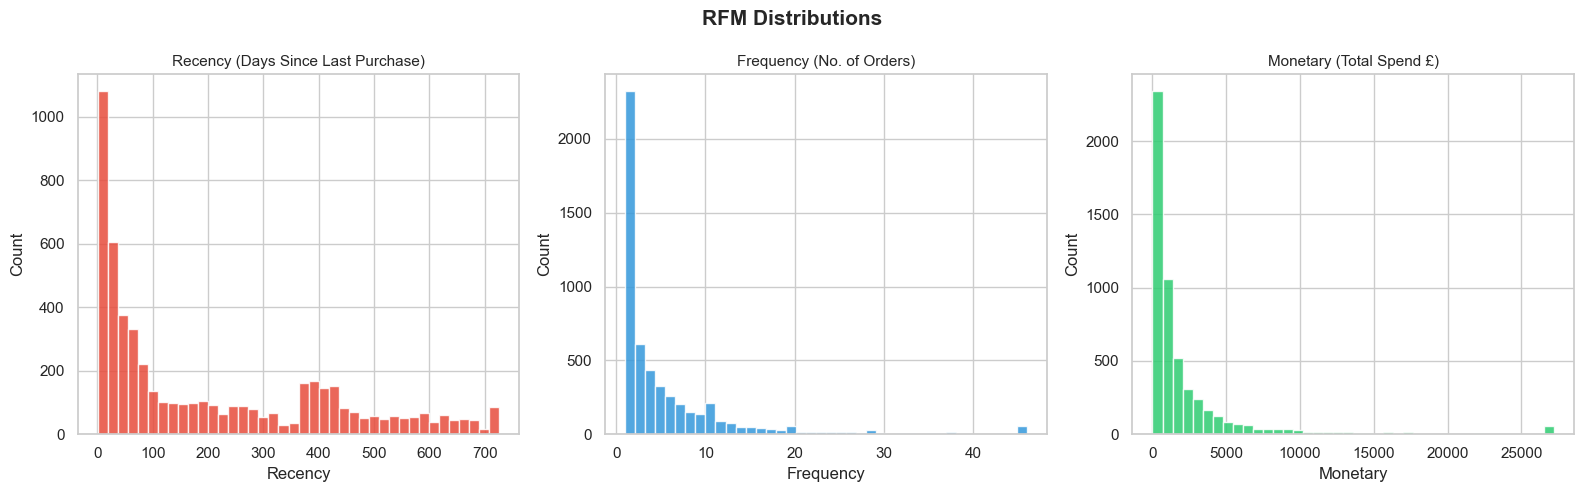

In [13]:
# ── RFM Distribution Plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Distributions', fontsize=15, fontweight='bold')

for ax, col, color, title in zip(
    axes,
    ['Recency', 'Frequency', 'Monetary'],
    ['#e74c3c', '#3498db', '#2ecc71'],
    ['Recency (Days Since Last Purchase)', 'Frequency (No. of Orders)', 'Monetary (Total Spend £)']
):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))  # Cap outliers for viz
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏷️ Phase 5 — Churn Labeling

**Definition:** A customer is considered **churned** if they have not purchased in the last **90 days** of the dataset window.

This is a business decision — in retail, 90 days of inactivity is a standard churn threshold.

📊 Churn Rate: 51.2%
Churned
Churned    2737
Active     2613
Name: count, dtype: int64


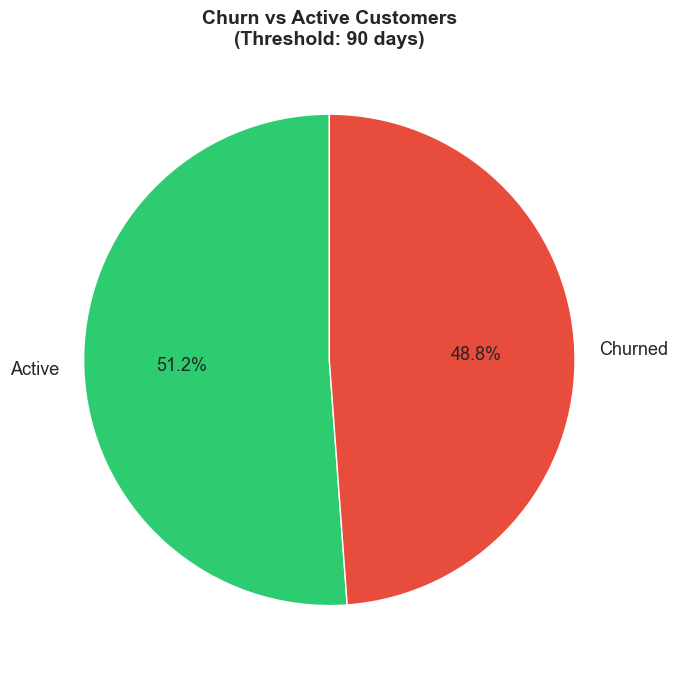

In [14]:
CHURN_DAYS = 90

rfm['Churned'] = (rfm['Recency'] > CHURN_DAYS).astype(int)

churn_rate = rfm['Churned'].mean() * 100
print(f'📊 Churn Rate: {churn_rate:.1f}%')
print(rfm['Churned'].value_counts().rename({0: 'Active', 1: 'Churned'}))

# Pie chart
labels = ['Active', 'Churned']
sizes  = rfm['Churned'].value_counts().values
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 13})
plt.title(f'Churn vs Active Customers\n(Threshold: {CHURN_DAYS} days)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_pie.png', dpi=150, bbox_inches='tight')
plt.show()

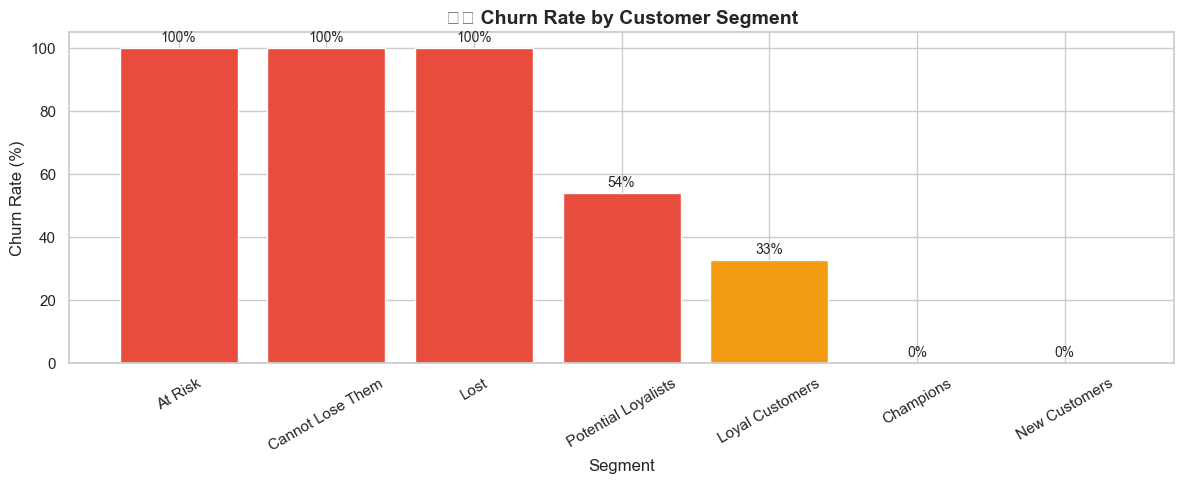

In [15]:
# ── Churn Rate by Segment ──
churn_by_segment = rfm.groupby('Segment')['Churned'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
bars = plt.bar(churn_by_segment.index, churn_by_segment.values,
               color=['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71'
                      for v in churn_by_segment.values])
plt.title('⚠️ Churn Rate by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Segment')
plt.xticks(rotation=30)
for bar, val in zip(bars, churn_by_segment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Phase 6 — XGBoost Churn Prediction Model

In [16]:
# ── Features & Target ──
features = ['Frequency', 'Monetary', 'F_Score', 'M_Score', 'RFM_Score']
target   = 'Churned'

X = rfm[features].astype(float)
y = rfm[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} | Test set: {X_test.shape[0]:,}')

# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Training set: 4,280 | Test set: 1,070


In [17]:
# ── Train XGBoost ──
scale_pos_weight = (y == 0).sum() / (y == 1).sum()  # Handle class imbalance

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'\n🎯 ROC-AUC Score: {roc_auc:.4f}')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))


🎯 ROC-AUC Score: 0.9821

📋 Classification Report:
              precision    recall  f1-score   support

      Active       0.93      0.89      0.91       523
     Churned       0.90      0.94      0.92       547

    accuracy                           0.92      1070
   macro avg       0.92      0.92      0.92      1070
weighted avg       0.92      0.92      0.92      1070



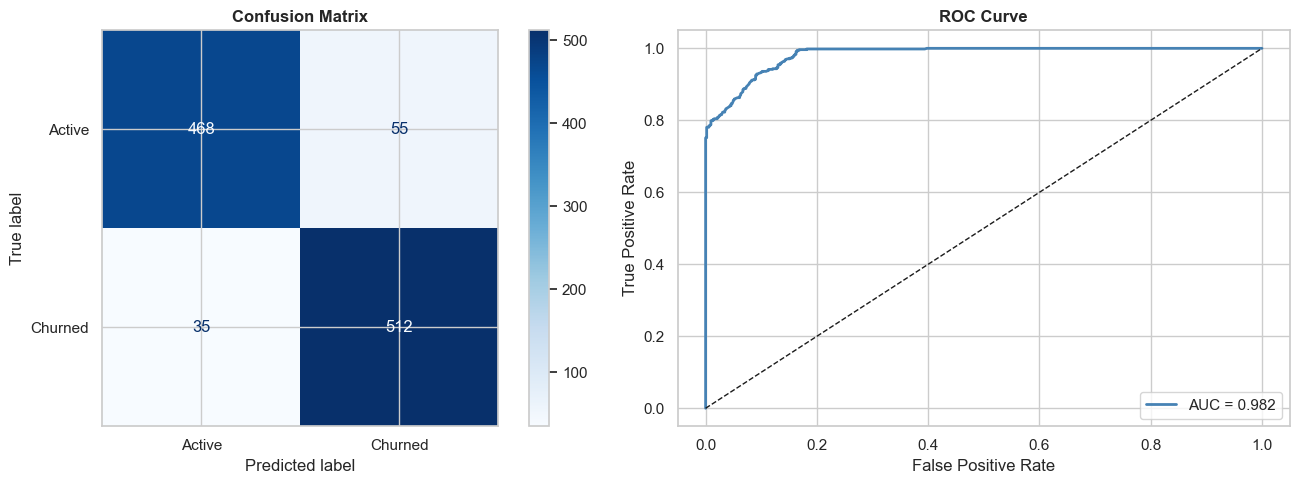

In [18]:
# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Active', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

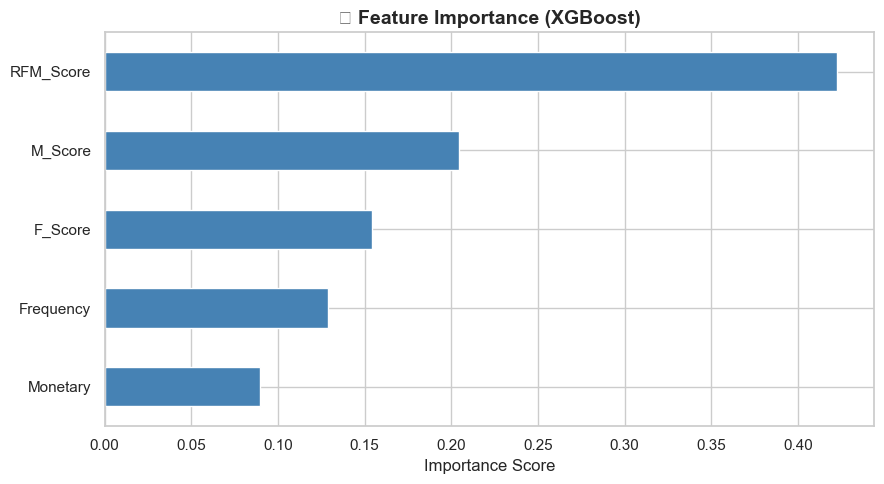

In [19]:
# ── Feature Importance ──
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('🔍 Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 Phase 7 — Export Data

In [20]:
# Add churn probability to full RFM table
X_all = scaler.transform(rfm[features].astype(float))
rfm['Churn_Probability'] = model.predict_proba(X_all)[:, 1]
rfm['Churn_Risk']        = pd.cut(
    rfm['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Revenue at risk = high risk customers' monetary value
revenue_at_risk = rfm[rfm['Churn_Risk'] == 'High Risk']['Monetary'].sum()
print(f'⚠️  Revenue at Risk (High Risk customers): £{revenue_at_risk:,.0f}')
print(f'   High Risk customers: {(rfm["Churn_Risk"] == "High Risk").sum():,}')

rfm.head()

⚠️  Revenue at Risk (High Risk customers): £2,663,199
   High Risk customers: 2,588


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Churned,Churn_Probability,Churn_Risk
0,12346,326,12,77556.46,2,5,5,12,At Risk,1,0.909633,High Risk
1,12608,405,1,415.79,2,1,2,5,Lost,1,0.983307,High Risk
2,12745,487,2,723.85,1,2,3,6,Lost,1,0.992540,High Risk
3,12746,541,1,254.55,1,1,1,3,Lost,1,0.997053,High Risk
4,12747,2,26,9276.54,5,5,5,15,Champions,0,0.001690,Low Risk


In [21]:
# ── Export 1: Full RFM + Churn table ──
rfm_export = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary',
                   'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
                   'Segment', 'Churned', 'Churn_Probability', 'Churn_Risk']].copy()
rfm_export.to_csv('rfm_churn_data.csv', index=False)
print('✅ Saved: rfm_churn_data.csv')

# ── Export 2: Monthly revenue for trend line ──
monthly_export = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum().reset_index()
monthly_export.columns = ['Month', 'Revenue']
monthly_export['Month'] = monthly_export['Month'].astype(str)
monthly_export.to_csv('monthly_revenue.csv', index=False)
print('✅ Saved: monthly_revenue.csv')

# ── Export 3: Segment summary for Power BI ──
segment_summary = rfm.groupby('Segment').agg(
    Customers        = ('Customer ID', 'count'),
    Avg_Recency      = ('Recency',     'mean'),
    Avg_Frequency    = ('Frequency',   'mean'),
    Avg_Monetary     = ('Monetary',    'mean'),
    Total_Revenue    = ('Monetary',    'sum'),
    Churn_Rate_Pct   = ('Churned',     lambda x: round(x.mean()*100, 1)),
    Revenue_At_Risk  = ('Monetary',    lambda x: x[rfm.loc[x.index, 'Churned']==1].sum())
).reset_index().round(2)
segment_summary.to_csv('segment_summary.csv', index=False)
print('✅ Saved: segment_summary.csv')

✅ Saved: rfm_churn_data.csv
✅ Saved: monthly_revenue.csv
✅ Saved: segment_summary.csv
